# Funding Analysis

## Objective

This notebook explores startup funding patterns across industries, countries, and startup outcomes.

### Key Questions

1. Which markets receive the most funding?
2. Which countries attract the most startup funding?
3. How does funding vary across startup statuses?
4. What is the relationship between funding rounds and total funding?
5. Which markets have the highest average funding per startup?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/raw/investments_VC.csv",
    encoding="latin1"
)

df.columns = df.columns.str.strip()

df["funding_total_usd"] = (
    df["funding_total_usd"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("-", "", regex=False)
    .str.strip()
)

df["funding_total_usd"] = pd.to_numeric(
    df["funding_total_usd"],
    errors="coerce"
)

df.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,4000000.0,operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,40000.0,operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000.0,operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,60000.0,operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Business Question

Which startup markets attract the highest total investment?

### Why This Matters

Understanding where investors allocate capital helps identify high-growth sectors and investment trends.

In [2]:
market_funding = (
    df.groupby("market")["funding_total_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

market_funding

market
Biotechnology           7.337295e+10
Mobile                  4.947011e+10
Software                4.222348e+10
Clean Technology        3.761994e+10
Health Care             2.946608e+10
E-Commerce              2.240839e+10
Enterprise Software     1.929719e+10
Finance                 1.737230e+10
Hardware + Software     1.281293e+10
Advertising             1.266066e+10
Semiconductors          1.234175e+10
Health and Wellness     1.220653e+10
Web Hosting             1.072166e+10
Technology              1.010378e+10
Curated Web             9.587998e+09
Name: funding_total_usd, dtype: float64

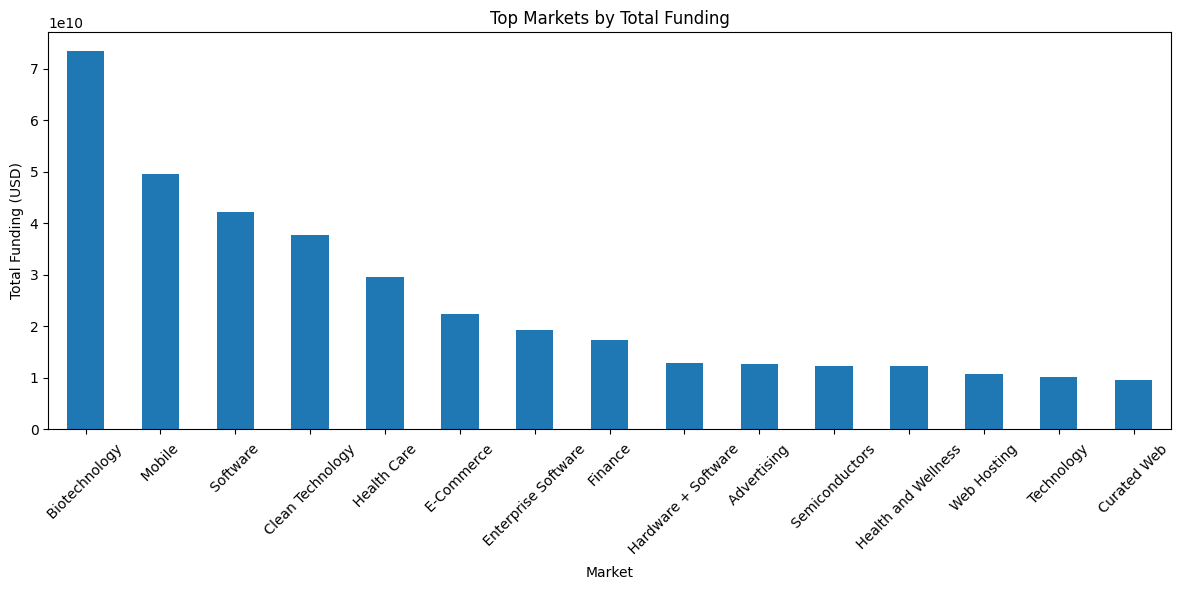

In [3]:
plt.figure(figsize=(12,6))

market_funding.plot(kind="bar")

plt.title("Top Markets by Total Funding")
plt.xlabel("Market")
plt.ylabel("Total Funding (USD)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Key Insight: Markets Receiving the Most Funding

Biotechnology received the highest total funding among all startup markets, followed by Mobile and Software.

Technology-driven sectors dominate overall investment activity, indicating strong investor interest in innovation-focused industries.

These results suggest that investors allocate substantial capital to sectors with high growth potential and significant research and development requirements.

## Business Question

Which countries attract the highest total startup funding?

### Why This Matters

Funding concentration by country helps identify the strongest startup ecosystems and the regions that attract the most investor capital.

In [4]:
country_funding = (
    df.groupby("country_code")["funding_total_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

country_funding

country_code
USA    4.642448e+11
CHN    3.557720e+10
GBR    2.349814e+10
IND    1.501171e+10
CAN    1.391417e+10
RUS    9.429262e+09
DEU    8.243664e+09
ISR    6.267080e+09
FRA    5.195064e+09
NLD    4.044213e+09
ESP    3.669193e+09
CHE    3.023008e+09
JPN    2.896595e+09
SWE    2.885797e+09
AUS    2.598953e+09
Name: funding_total_usd, dtype: float64

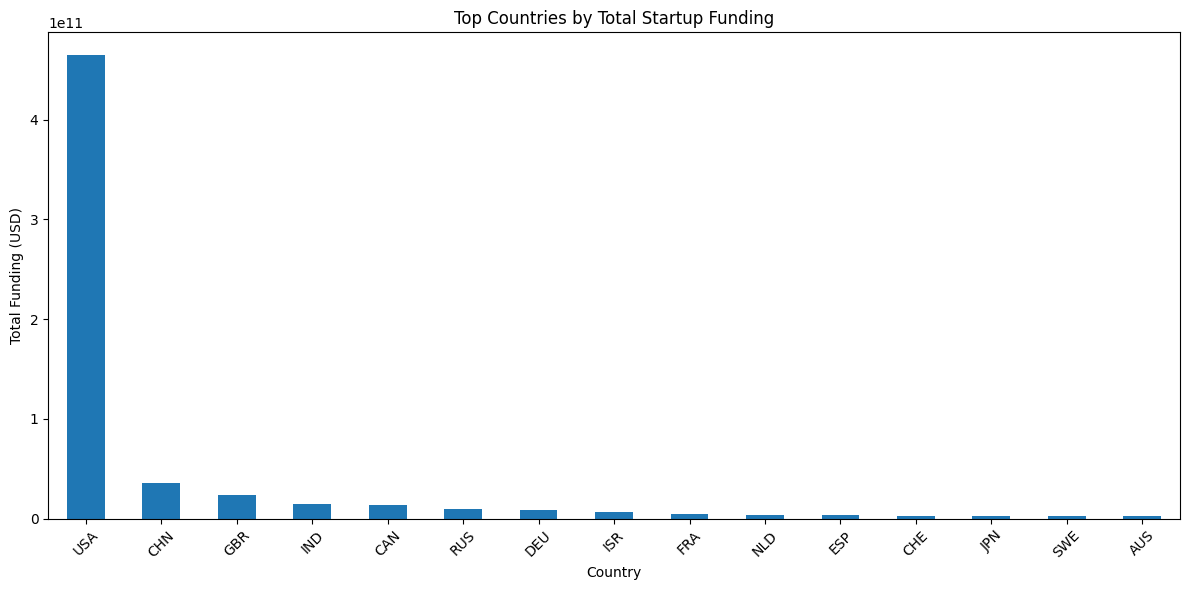

In [5]:
plt.figure(figsize=(12,6))

country_funding.plot(kind="bar")

plt.title("Top Countries by Total Startup Funding")
plt.xlabel("Country")
plt.ylabel("Total Funding (USD)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Key Insight: Countries Attracting the Most Startup Funding

The United States dominates global startup funding by a significant margin, attracting substantially more investment than any other country in the dataset.

### Findings

- The USA received the highest total startup funding.
- China ranks second but remains far behind the USA.
- The United Kingdom, India, and Canada are also among the top-funded startup ecosystems.
- European countries such as Germany, France, Spain, and Switzerland appear in the top funding destinations but receive considerably less funding than the leading countries.

### Interpretation

The results highlight the strength of the United States startup ecosystem, which benefits from:
- A large venture capital market
- Strong technology hubs
- Access to global investors
- A mature startup infrastructure

The presence of China, India, and the United Kingdom among the top-funded countries demonstrates the growing importance of startup ecosystems outside the United States.

### Conclusion

Startup funding is highly concentrated geographically, with the United States serving as the primary destination for venture capital investment worldwide.

## Business Question

Which startup markets receive the highest average funding per startup?

### Why This Matters

Total funding can be influenced by the number of startups in a market.

Average funding per startup helps identify industries where individual startups attract the largest investments.

In [6]:
market_avg_funding = (
    df.groupby("market")["funding_total_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

market_avg_funding

market
Natural Gas Uses            4.000000e+08
Film Production             2.626750e+08
Oil and Gas                 2.355225e+08
Trading                     1.600852e+08
Content Creators            1.364675e+08
Solar                       1.289295e+08
Recreation                  1.286600e+08
Development Platforms       1.258555e+08
Custom Retail               1.196578e+08
Physicians                  1.182621e+08
Hospitals                   1.105050e+08
B2B Express Delivery        1.050000e+08
Cloud-Based Music           1.040000e+08
Chemicals                   9.066943e+07
Communications Hardware     8.624276e+07
Name: funding_total_usd, dtype: float64

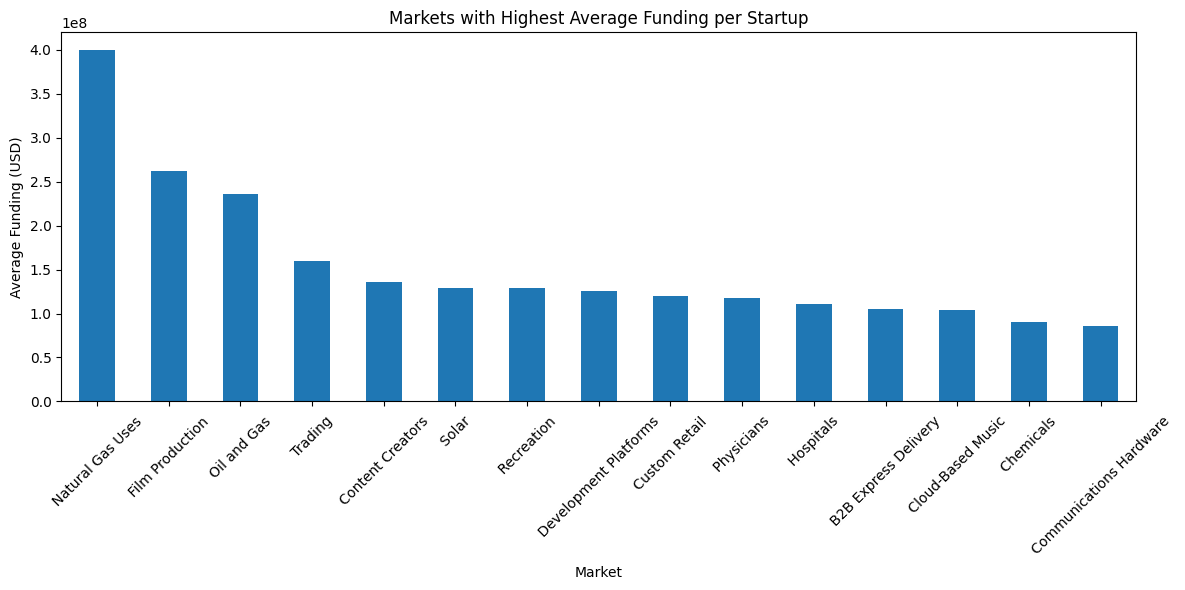

In [7]:
plt.figure(figsize=(12,6))

market_avg_funding.plot(kind="bar")

plt.title("Markets with Highest Average Funding per Startup")
plt.xlabel("Market")
plt.ylabel("Average Funding (USD)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Key Insight: Markets with the Highest Average Funding per Startup

This analysis examines the average funding received by startups in each market.

### Findings

- Natural Gas Uses startups receive the highest average funding per startup.
- Film Production and Oil & Gas also rank among the top-funded industries on a per-startup basis.
- Several specialized sectors such as Solar, Hospitals, Physicians, and Chemicals appear in the top rankings.
- Traditional technology sectors such as Software and Mobile are not among the highest average-funded markets.

### Interpretation

The results suggest that capital-intensive industries require substantially larger investments per company.

Industries such as energy, healthcare, infrastructure, and industrial sectors often require:
- Significant research and development
- Specialized equipment
- Regulatory approvals
- Large-scale operational investments

As a result, individual startups in these sectors attract larger funding rounds compared to many software-focused businesses.

### Conclusion

While technology markets receive the highest total investment overall, capital-intensive industries receive the highest average funding per startup, highlighting the different investment requirements across sectors.

## Business Question

Is there a relationship between the number of funding rounds and the total funding raised?

### Why This Matters

Understanding this relationship helps determine whether startups that progress through more funding rounds tend to attract larger investments.

In [8]:
sample_df = df[
    ["funding_rounds", "funding_total_usd"]
].dropna()

sample_df.shape

(40907, 2)

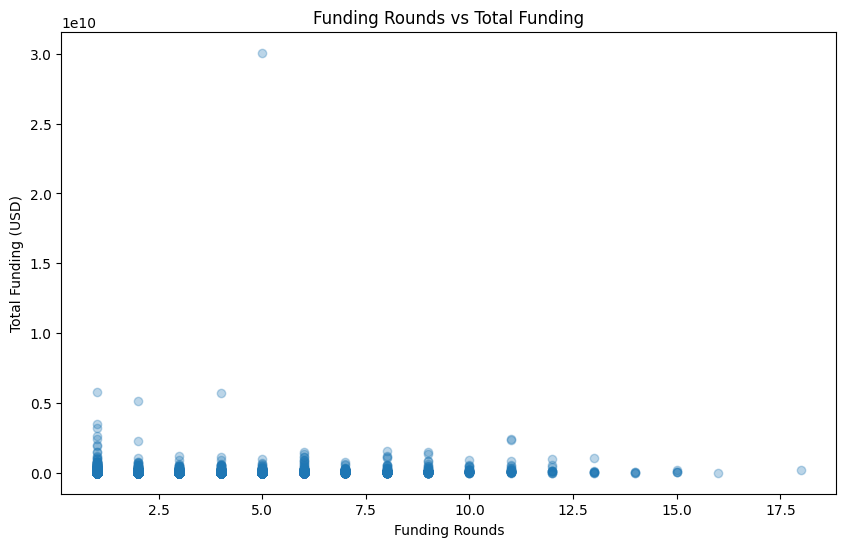

In [9]:
plt.figure(figsize=(10,6))

plt.scatter(
    sample_df["funding_rounds"],
    sample_df["funding_total_usd"],
    alpha=0.3
)

plt.title("Funding Rounds vs Total Funding")
plt.xlabel("Funding Rounds")
plt.ylabel("Total Funding (USD)")

plt.show()

In [10]:
sample_df[["funding_rounds", "funding_total_usd"]].corr()

,funding_rounds,funding_total_usd
funding_rounds,1.000000,0.105255
funding_total_usd,0.105255,1.000000


## Key Insight: Funding Rounds vs Total Funding

This analysis explores whether startups that complete more funding rounds tend to raise more money overall.

### Findings

- The correlation between funding rounds and total funding is approximately **0.11**.
- This indicates a very weak positive relationship.
- The scatter plot shows substantial variation in funding amounts across all funding-round counts.
- Several startups raised extremely large amounts of funding despite having relatively few funding rounds.

### Interpretation

Although startups with more funding rounds may generally raise more capital, the relationship is weak.

This suggests that:
- The number of funding rounds alone is not a strong predictor of total funding.
- Funding size depends on many additional factors such as industry, company maturity, market opportunity, and investor interest.
- Some startups secure very large investments in only a few funding rounds.

### Conclusion

The number of funding rounds has only a limited relationship with total funding raised. Startup funding outcomes are influenced by multiple factors beyond simply the frequency of fundraising.

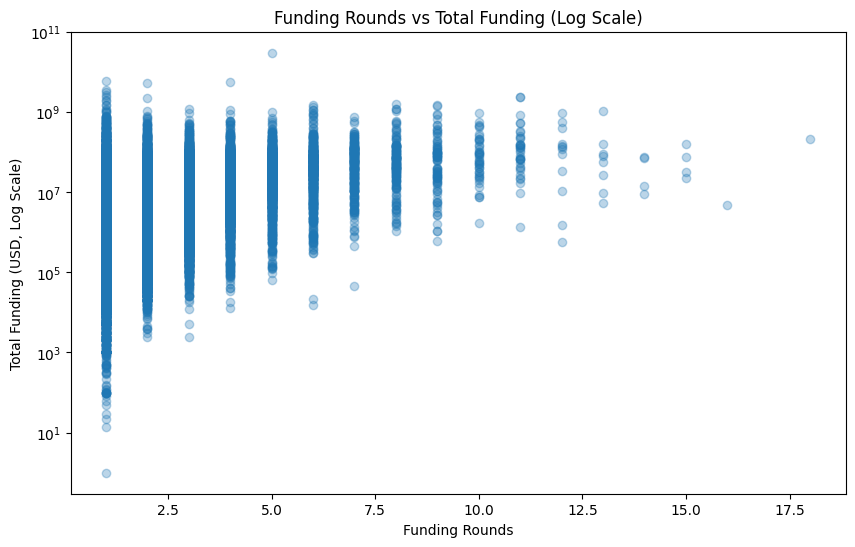

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(
    sample_df["funding_rounds"],
    sample_df["funding_total_usd"],
    alpha=0.3
)

plt.yscale("log")

plt.title("Funding Rounds vs Total Funding (Log Scale)")
plt.xlabel("Funding Rounds")
plt.ylabel("Total Funding (USD, Log Scale)")

plt.show()

## Key Insight: Funding Rounds vs Total Funding

This analysis examines the relationship between the number of funding rounds and the total funding raised by startups.

### Findings

- The correlation between funding rounds and total funding is approximately **0.11**, indicating a weak positive relationship.
- The log-scale scatter plot reveals that startups with more funding rounds generally tend to raise larger amounts of capital.
- However, substantial variation exists at every funding-round level.
- Several startups raise very large amounts of funding despite completing only a few funding rounds.

### Interpretation

While additional funding rounds often coincide with higher funding totals, the relationship is not strong enough to be considered a reliable predictor.

Factors such as:
- Industry sector
- Business model
- Company maturity
- Market opportunity
- Investor confidence

appear to have a significant influence on funding outcomes.

### Conclusion

Funding rounds contribute to fundraising success, but they represent only one part of the funding equation. Startup funding is driven by multiple business and market factors beyond the number of investment rounds.

Which startup statuses receive the most funding?

In [12]:
status_funding = (
    df.groupby("status")["funding_total_usd"]
    .sum()
    .sort_values(ascending=False)
)

status_funding

status
operating    5.417878e+11
acquired     7.663035e+10
closed       1.828137e+10
Name: funding_total_usd, dtype: float64

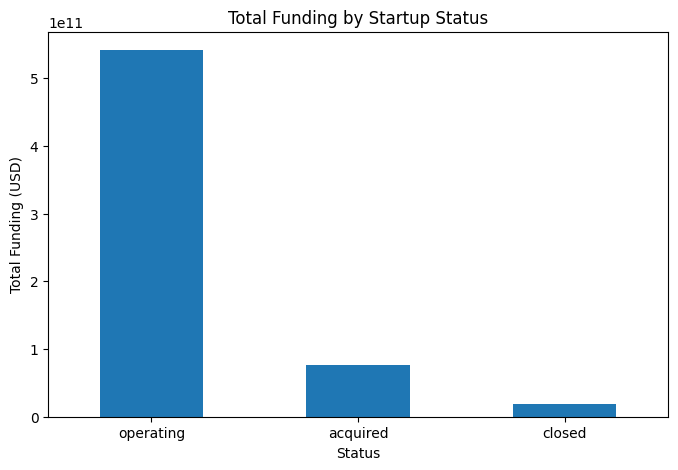

In [13]:
plt.figure(figsize=(8,5))

status_funding.plot(kind="bar")

plt.title("Total Funding by Startup Status")
plt.xlabel("Status")
plt.ylabel("Total Funding (USD)")

plt.xticks(rotation=0)

plt.show()

## Key Insight: Funding by Startup Status

This analysis compares the total funding received by startups based on their current status.

### Findings

- Operating startups received the highest total amount of funding.
- Acquired startups received the second-highest amount of funding.
- Closed startups attracted the lowest total funding.

### Interpretation

The dominance of operating startups is partly explained by their large representation in the dataset.

However, the substantial funding received by acquired startups suggests that many successful exits occur among well-funded companies.

The comparatively lower funding observed for closed startups may indicate difficulties in attracting investment or sustaining growth over time.

### Conclusion

Funding appears to be concentrated among active and successful startups, while closed startups account for a much smaller share of total investment capital.

Which status receives the highest median funding per startup?

In [14]:
status_median_funding = (
    df.groupby("status")["funding_total_usd"]
    .median()
    .sort_values(ascending=False)
)

status_median_funding

status
acquired     8382400.0
operating    1757977.5
closed       1000000.0
Name: funding_total_usd, dtype: float64

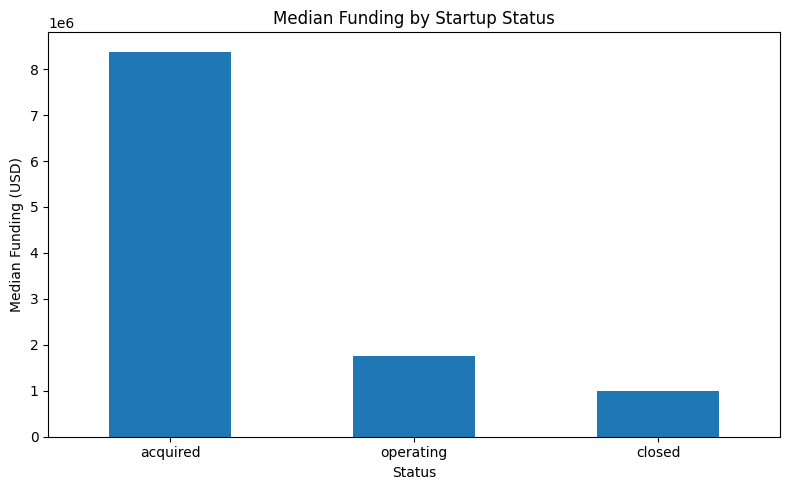

In [15]:
plt.figure(figsize=(8,5))

status_median_funding.plot(kind="bar")

plt.title("Median Funding by Startup Status")
plt.xlabel("Status")
plt.ylabel("Median Funding (USD)")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## Key Insight: Median Funding by Startup Status

This analysis compares the median funding raised by startups across different outcomes.

### Findings

- Acquired startups have the highest median funding, at approximately **$8.4 million**.
- Operating startups have a median funding of approximately **$1.8 million**.
- Closed startups have the lowest median funding, at approximately **$1.0 million**.

### Interpretation

The results suggest that startups which are eventually acquired tend to secure significantly more funding than both operating and closed startups.

Higher funding levels may provide:
- Greater resources for growth and expansion
- Stronger market presence
- Increased attractiveness to potential acquirers

Meanwhile, closed startups generally raise less capital, which may reflect challenges in scaling operations or sustaining business growth.

### Conclusion

Funding appears to be strongly associated with startup outcomes. Acquired startups typically attract substantially more investment than operating or closed startups, indicating that well-funded companies are more likely to achieve successful exits.